Sales Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB
None

First 5 rows:
         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North  

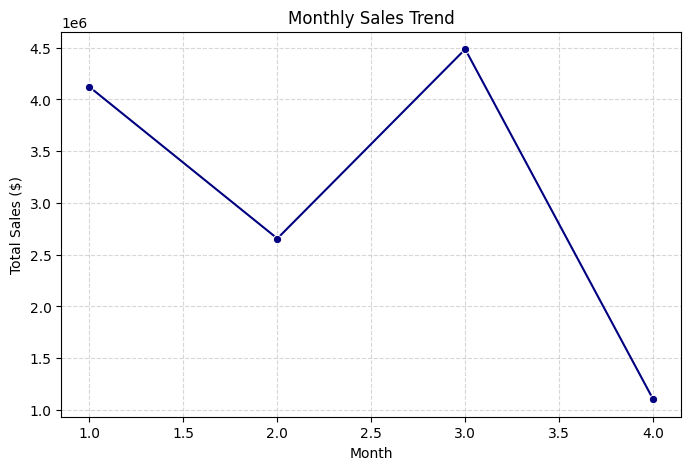

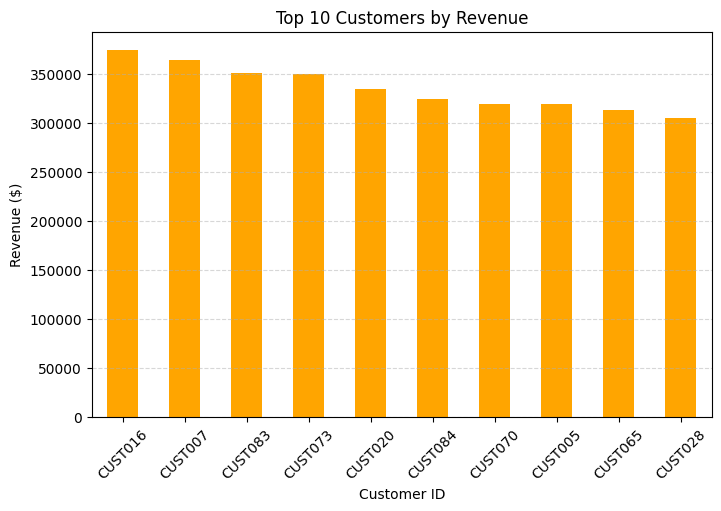

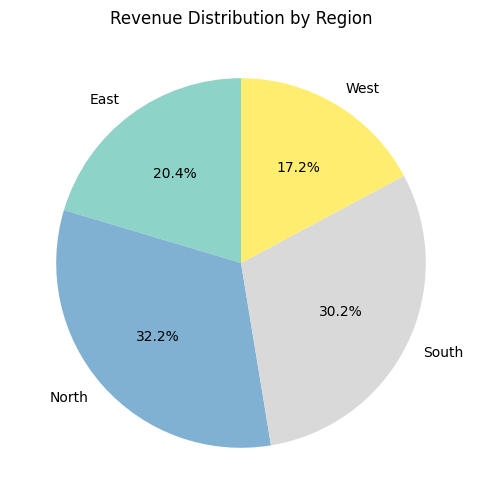

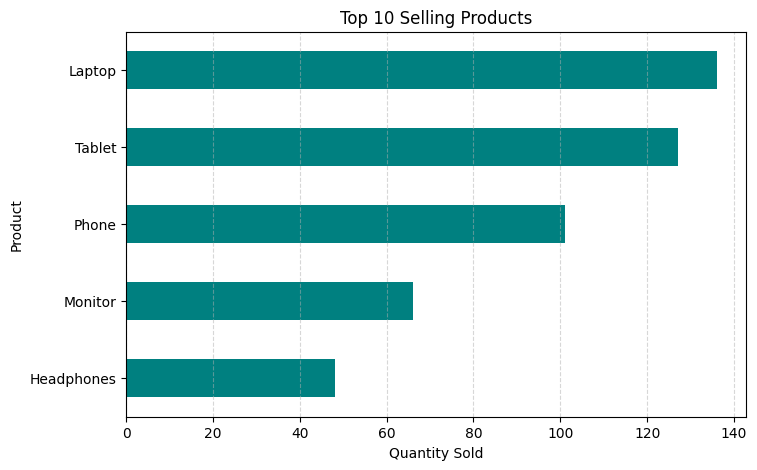

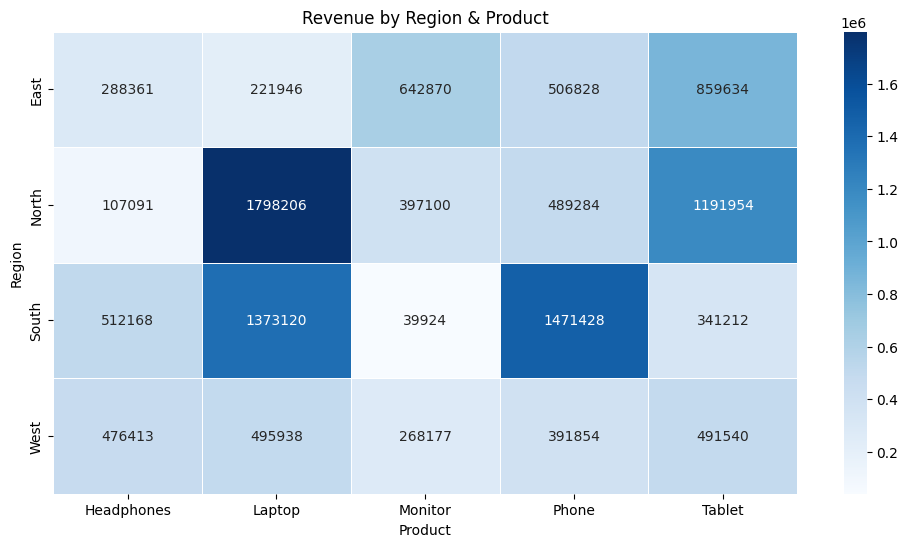

CUSTOMER SALES ANALYSIS REPORT
Total Revenue: $12,365,048
Total Customers: 100
Average Order Value: $123,650.48
Top Customer: CUST016 - $373,932


In [40]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sales = pd.read_csv('sales_data.csv')
print("Sales Dataset Info:")
print(sales.info())
print("\nFirst 5 rows:")
print(sales.head())
print("\nMissing values per column:")
print(sales.isnull().sum())


sales['Date'] = pd.to_datetime(sales['Date'])
sales['Year'] = sales['Date'].dt.year
sales['Month'] = sales['Date'].dt.month
sales['Month_Name'] = sales['Date'].dt.month_name()
sales['Day'] = sales['Date'].dt.day
sales['Total_Sales'] = sales['Quantity'] * sales['Price']
sales.fillna(0, inplace=True)


top_customers = sales.groupby('Customer_ID')['Total_Sales'].sum().sort_values(ascending=False)

clv = sales.groupby('Customer_ID')['Total_Sales'].sum().reset_index()

region_sales = sales.groupby('Region')['Total_Sales'].sum()


monthly_sales = sales.groupby('Month')['Total_Sales'].sum().reset_index()
top_products = sales.groupby('Product')['Quantity'].sum().sort_values(ascending=False)


pivot_table = pd.pivot_table(
    sales,
    values='Total_Sales',
    index='Region',
    columns='Product',
    aggfunc='sum',
    fill_value=0
)

high_value_north = sales[(sales['Region'] == 'North') & (sales['Total_Sales'] > 1000)]


plt.figure(figsize=(8,5))
sns.lineplot(data=monthly_sales, x='Month', y='Total_Sales', marker='o', color='navy')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

plt.figure(figsize=(8,5))
top_customers.head(10).plot(kind='bar', color='orange')
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

plt.figure(figsize=(6,6))
region_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='Set3')
plt.title("Revenue Distribution by Region")
plt.ylabel("")
plt.show()

plt.figure(figsize=(8,5))
top_products.head(10).sort_values().plot(kind='barh', color='teal')
plt.title("Top 10 Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

plt.figure(figsize=(12,6))
sns.heatmap(pivot_table, cmap="Blues", annot=True, fmt="d", linewidths=0.5)
plt.title("Revenue by Region & Product")
plt.ylabel("Region")
plt.xlabel("Product")
plt.show()


total_revenue = sales['Total_Sales'].sum()
total_customers = sales['Customer_ID'].nunique()
avg_order_value = sales['Total_Sales'].mean()
top_customer = top_customers.head(1)

print("CUSTOMER SALES ANALYSIS REPORT")
print(f"Total Revenue: ${total_revenue:,.0f}")
print(f"Total Customers: {total_customers}")
print(f"Average Order Value: ${avg_order_value:,.2f}")
print(f"Top Customer: {top_customer.index[0]} - ${top_customer.values[0]:,.0f}")
